In [2]:
# should run every time you open the notebook (connect to the kernel)
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <BBF229FE-E7FC-30D6-AD24-713D50386A7C> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [3]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
# download data from yfinance

# download data from yfinance
apple = yf.download('AAPL', start='2020-01-01', end='2025-12-31', interval='1mo')

# show data
apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-01,74.608574,79.029500,70.568509,71.409785,2934370400
2020-02-01,65.894470,78.877633,61.798968,73.352676,3019279200
2020-03-01,61.443050,73.454276,51.372084,68.206161,6280072400
2020-04-01,70.989685,71.166075,57.241173,59.560783,3265299200
2020-05-01,76.822556,78.344796,69.068780,69.165429,2805936000


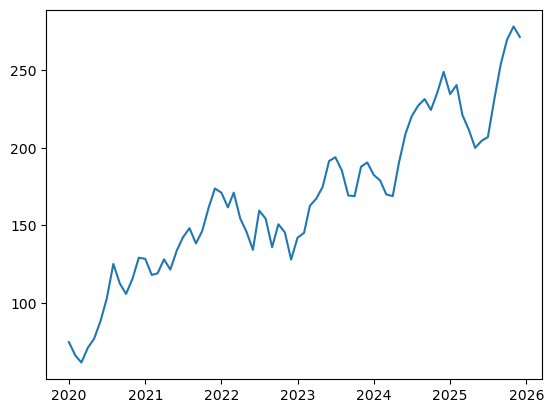

In [5]:
# plot and save as apple[close] as .csv
plt.plot(apple['Close'])
plt.show()
apple['Close'].to_csv('apple_close.csv')

In [8]:
%%R
# now use R in ipynb to make test
library(exuber)

# 1. Load series
dat <- read.csv('apple_close.csv')
y   <- ts(dat$AAPL)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 1999, seed = 123)

options(digits = 10)
print(res)
print(cv)


── radf (minw = 15, lag = 0) ───────────────────────────────────────────────────

       id         adf        sadf      gsadf
  series1  -0.7194421  -0.1806383  0.3639708

  gsadf_panel
    0.3639708


── Monte Carlo (minw = 15, nrep = 1999) ────────────────────────────────────────

  sig          adf       sadf     gsadf
   90  -0.43958184  0.9225288  1.642728
   95  -0.08639245  1.2484120  1.964286
   99   0.64923932  1.8616799  2.593994

